<a href="https://colab.research.google.com/github/hania-sajjad/WEEK-1-TASK/blob/main/EDA_Online_Retail.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Display all columns (do not hide)
pd.set_option('display.max_columns', None)

In [ ]:
#UPLOAD DATASET
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#LOAD DATASET
file_path = "/content/drive/MyDrive/Week1Data/online_retail_II.xlsx"
df = pd.read_excel(file_path)

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [ ]:
#BASIC INFORMATION
#Shape
print("Shape of the dataset:", df.shape)

#Column Names
print("\nColumn Names:")
print(df.columns)

#Data Type of each Column
print("\nData Types:")
print(df.dtypes)

Shape of the dataset: (525461, 8)

Column Names:
Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country'],
      dtype='object')

Data Types:
Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
Price                 float64
Customer ID           float64
Country                object
dtype: object


In [ ]:
#DATASET INFORMATION
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      525461 non-null  object        
 1   StockCode    525461 non-null  object        
 2   Description  522533 non-null  object        
 3   Quantity     525461 non-null  int64         
 4   InvoiceDate  525461 non-null  datetime64[ns]
 5   Price        525461 non-null  float64       
 6   Customer ID  417534 non-null  float64       
 7   Country      525461 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 32.1+ MB


In [ ]:
#STATISTICAL SUMMARY
df.describe()

,Quantity,InvoiceDate,Price,Customer ID
count,525461.000000,525461,525461.000000,417534.000000
mean,10.337667,2010-06-28 11:37:36.845017856,4.688834,15360.645478
min,-9600.000000,2009-12-01 07:45:00,-53594.360000,12346.000000
25%,1.000000,2010-03-21 12:20:00,1.250000,13983.000000
50%,3.000000,2010-07-06 09:51:00,2.100000,15311.000000
75%,10.000000,2010-10-15 12:45:00,4.210000,16799.000000
max,19152.000000,2010-12-09 20:01:00,25111.090000,18287.000000
std,107.424110,NaN,146.126914,1680.811316


In [ ]:
#MISSING VALUE ANALYSIS
#Missing Values in each Column
missing_values = df.isnull().sum()
print("Missing Values in Each Column:")
print(missing_values)

#Missing Value Percentage
missing_percentage = (df.isnull().sum() / len(df)) * 100
print("Percentage of Missing Values:")
print(missing_percentage)

Missing Values in Each Column:
Invoice             0
StockCode           0
Description      2928
Quantity            0
InvoiceDate         0
Price               0
Customer ID    107927
Country             0
dtype: int64
Percentage of Missing Values:
Invoice         0.000000
StockCode       0.000000
Description     0.557225
Quantity        0.000000
InvoiceDate     0.000000
Price           0.000000
Customer ID    20.539488
Country         0.000000
dtype: float64


In [ ]:
#DUPLICATE ROWS ANALYSIS
duplicate_rows = df.duplicated().sum()
print("Number of Duplicate Rows:", duplicate_rows)

Number of Duplicate Rows: 6865


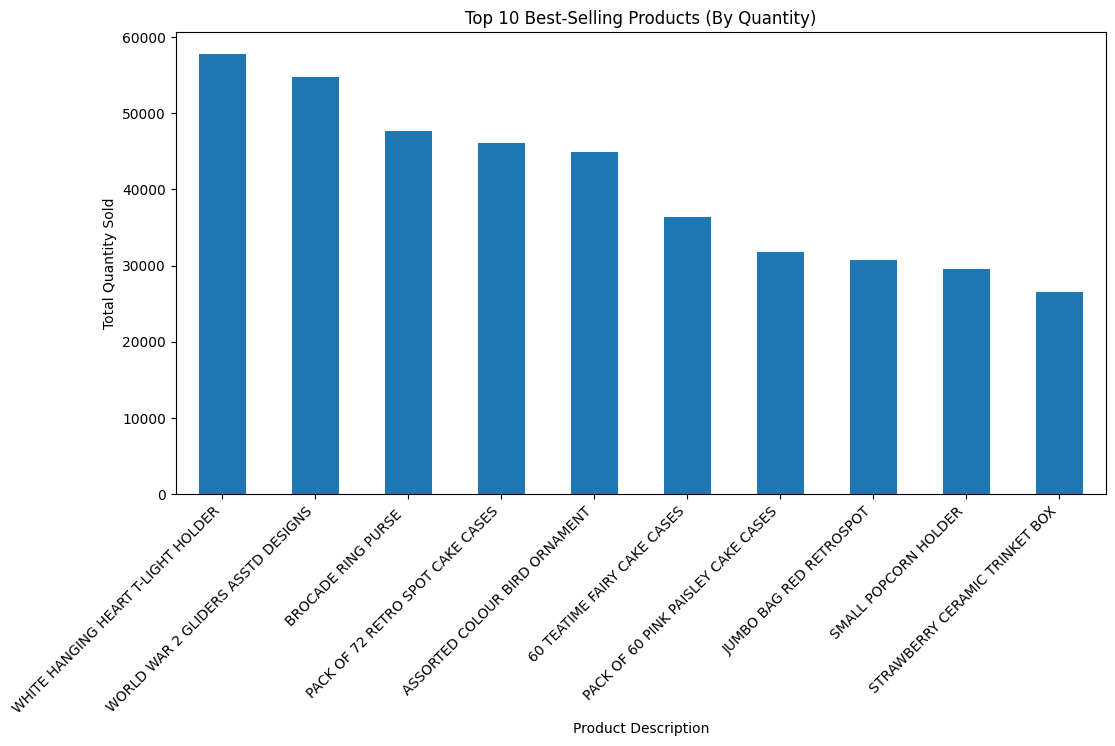

In [ ]:
#TOP 10 PRODUCTS BY QUANTITY
top_products_qty = df.groupby("Description")["Quantity"].sum().sort_values(ascending=False).head(10)
top_products_qty

#Plot
plt.figure(figsize=(12,6))

top_products_qty.plot(kind="bar")

plt.title("Top 10 Best-Selling Products (By Quantity)")
plt.xlabel("Product Description")
plt.ylabel("Total Quantity Sold")
plt.xticks(rotation=45, ha='right')

plt.show()

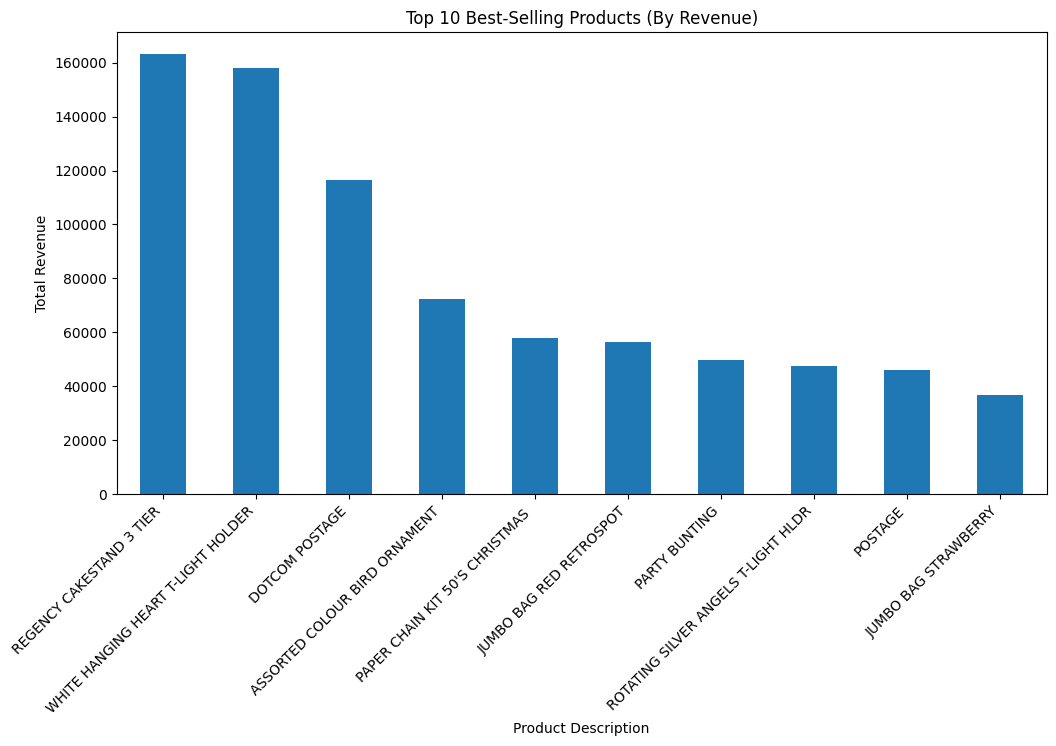

In [ ]:
#TOP 10 PRODUCTS BY REVENUE
df["Revenue"] = df["Quantity"] * df["Price"]  #Create Column
top_products_revenue = df.groupby("Description")["Revenue"].sum().sort_values(ascending=False).head(10)
top_products_revenue

#Plot
plt.figure(figsize=(12,6))

top_products_revenue.plot(kind="bar")

plt.title("Top 10 Best-Selling Products (By Revenue)")
plt.xlabel("Product Description")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45, ha='right')

plt.show()

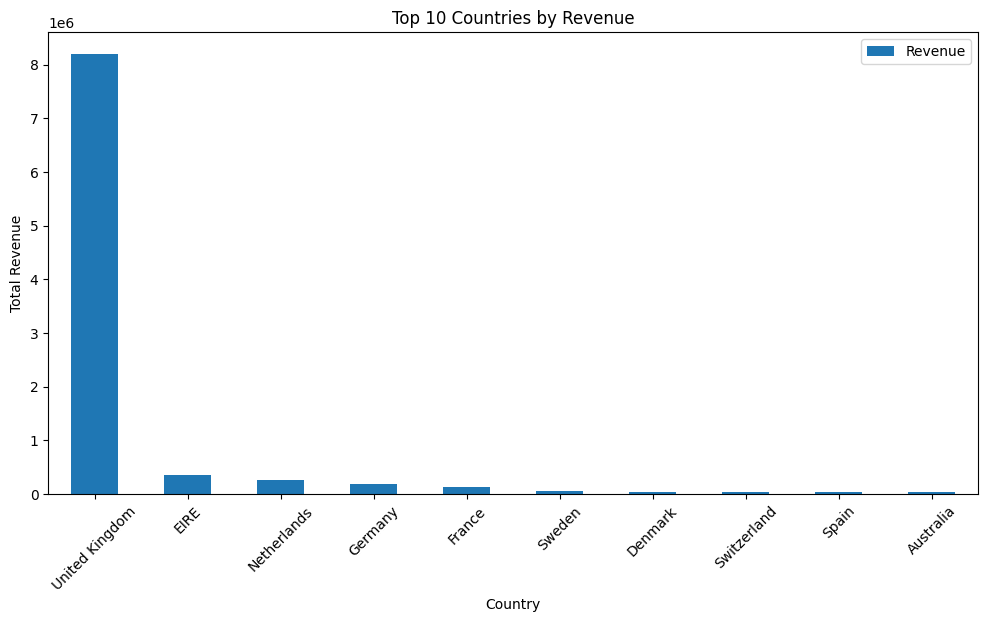

In [13]:
#SALES PERFORMANCE BY COUNTRY
country_sales = (
    df.groupby("Country")["Revenue"]
      .sum()
      .sort_values(ascending=False)
)

country_sales.head(10)

#Plot TOP 10 Countries
plt.figure(figsize=(12,6))

country_sales.head(10).plot(kind="bar")

plt.title("Top 10 Countries by Revenue")
plt.xlabel("Country")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)

plt.legend(["Revenue"])

plt.show()